# Asteroid Hazard Classifier - Exploratory Data Analysis

NASA NEO (Near-Earth Object) data diye asteroid hazardous naki na classify korার project.

## 1. Load Dataset

In [1]:
# Import required libraries for data handling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Find the exact file path (Kaggle paths can be nested)
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/rozamakima77/nasa-asteroids-classification/nasa.csv


## 2. Data Overview

In [2]:
# Load the NASA asteroid dataset
df = pd.read_csv('/kaggle/input/datasets/rozamakima77/nasa-asteroids-classification/nasa.csv')

# Preview first 5 rows
df.head()

,Neo Reference ID,Name,Absolute Magnitude,Est Dia in KM(min),Est Dia in KM(max),Est Dia in M(min),Est Dia in M(max),Est Dia in Miles(min),Est Dia in Miles(max),Est Dia in Feet(min),...,Asc Node Longitude,Orbital Period,Perihelion Distance,Perihelion Arg,Aphelion Dist,Perihelion Time,Mean Anomaly,Mean Motion,Equinox,Hazardous
0,3703080,3703080,21.6,0.127220,0.284472,127.219879,284.472297,0.079051,0.176763,417.388066,...,314.373913,609.599786,0.808259,57.257470,2.005764,2.458162e+06,264.837533,0.590551,J2000,True
1,3723955,3723955,21.3,0.146068,0.326618,146.067964,326.617897,0.090762,0.202951,479.225620,...,136.717242,425.869294,0.718200,313.091975,1.497352,2.457795e+06,173.741112,0.845330,J2000,False
2,2446862,2446862,20.3,0.231502,0.517654,231.502122,517.654482,0.143849,0.321655,759.521423,...,259.475979,643.580228,0.950791,248.415038,1.966857,2.458120e+06,292.893654,0.559371,J2000,True
3,3092506,3092506,27.4,0.008801,0.019681,8.801465,19.680675,0.005469,0.012229,28.876199,...,57.173266,514.082140,0.983902,18.707701,1.527904,2.457902e+06,68.741007,0.700277,J2000,False
4,3514799,3514799,21.6,0.127220,0.284472,127.219879,284.472297,0.079051,0.176763,417.388066,...,84.629307,495.597821,0.967687,158.263596,1.483543,2.457814e+06,135.142133,0.726395,J2000,True


In [3]:
# See all column names as a list
print(df.columns.tolist())

['Neo Reference ID', 'Name', 'Absolute Magnitude', 'Est Dia in KM(min)', 'Est Dia in KM(max)', 'Est Dia in M(min)', 'Est Dia in M(max)', 'Est Dia in Miles(min)', 'Est Dia in Miles(max)', 'Est Dia in Feet(min)', 'Est Dia in Feet(max)', 'Close Approach Date', 'Epoch Date Close Approach', 'Relative Velocity km per sec', 'Relative Velocity km per hr', 'Miles per hour', 'Miss Dist.(Astronomical)', 'Miss Dist.(lunar)', 'Miss Dist.(kilometers)', 'Miss Dist.(miles)', 'Orbiting Body', 'Orbit ID', 'Orbit Determination Date', 'Orbit Uncertainity', 'Minimum Orbit Intersection', 'Jupiter Tisserand Invariant', 'Epoch Osculation', 'Eccentricity', 'Semi Major Axis', 'Inclination', 'Asc Node Longitude', 'Orbital Period', 'Perihelion Distance', 'Perihelion Arg', 'Aphelion Dist', 'Perihelion Time', 'Mean Anomaly', 'Mean Motion', 'Equinox', 'Hazardous']


## 3. Dataset Shape and Missing Values

In [4]:
# Check total rows/columns and inspect data types + missing values
print(df.shape)
df.info()

(4687, 40)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4687 entries, 0 to 4686
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Neo Reference ID              4687 non-null   int64  
 1   Name                          4687 non-null   int64  
 2   Absolute Magnitude            4687 non-null   float64
 3   Est Dia in KM(min)            4687 non-null   float64
 4   Est Dia in KM(max)            4687 non-null   float64
 5   Est Dia in M(min)             4687 non-null   float64
 6   Est Dia in M(max)             4687 non-null   float64
 7   Est Dia in Miles(min)         4687 non-null   float64
 8   Est Dia in Miles(max)         4687 non-null   float64
 9   Est Dia in Feet(min)          4687 non-null   float64
 10  Est Dia in Feet(max)          4687 non-null   float64
 11  Close Approach Date           4687 non-null   object 
 12  Epoch Date Close Approach     4687 non-null   int64

## 4. Target Variable Distribution

In [5]:
# Check how many Hazardous vs Not Hazardous asteroids exist
print(df['Hazardous'].value_counts())

# Also check as percentage
print(df['Hazardous'].value_counts(normalize=True) * 100)

Hazardous
False    3932
True      755
Name: count, dtype: int64
Hazardous
False    83.891615
True     16.108385
Name: proportion, dtype: float64


## 5. Visualizing Class Distribution

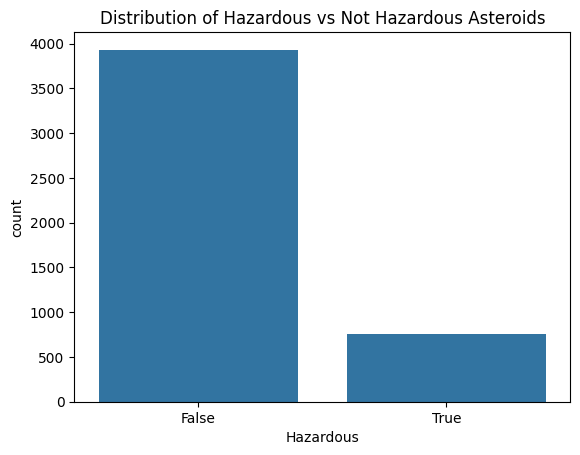

In [6]:
# Visualize the class imbalance as a bar chart
sns.countplot(data=df, x='Hazardous')
plt.title('Distribution of Hazardous vs Not Hazardous Asteroids')
plt.savefig('/kaggle/working/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Checking Redundant Unit Columns

Confirming that diameter, velocity, and distance columns measured in different units are perfectly correlated (redundant).

In [7]:
# Check correlation between the different unit versions of diameter
diameter_cols = ['Est Dia in KM(min)', 'Est Dia in M(min)', 
                  'Est Dia in Miles(min)', 'Est Dia in Feet(min)']
print(df[diameter_cols].corr())

                       Est Dia in KM(min)  Est Dia in M(min)  \
Est Dia in KM(min)                    1.0                1.0   
Est Dia in M(min)                     1.0                1.0   
Est Dia in Miles(min)                 1.0                1.0   
Est Dia in Feet(min)                  1.0                1.0   

                       Est Dia in Miles(min)  Est Dia in Feet(min)  
Est Dia in KM(min)                       1.0                   1.0  
Est Dia in M(min)                        1.0                   1.0  
Est Dia in Miles(min)                    1.0                   1.0  
Est Dia in Feet(min)                     1.0                   1.0  


## 7. Checking Velocity and Distance Redundancy

In [8]:
# Check correlation between different unit versions of velocity
velocity_cols = ['Relative Velocity km per sec', 'Relative Velocity km per hr', 'Miles per hour']
print("Velocity correlation:")
print(df[velocity_cols].corr())

# Check correlation between different unit versions of miss distance
distance_cols = ['Miss Dist.(Astronomical)', 'Miss Dist.(lunar)', 'Miss Dist.(kilometers)', 'Miss Dist.(miles)']
print("\nDistance correlation:")
print(df[distance_cols].corr())

Velocity correlation:
                              Relative Velocity km per sec  \
Relative Velocity km per sec                           1.0   
Relative Velocity km per hr                            1.0   
Miles per hour                                         1.0   

                              Relative Velocity km per hr  Miles per hour  
Relative Velocity km per sec                          1.0             1.0  
Relative Velocity km per hr                           1.0             1.0  
Miles per hour                                        1.0             1.0  

Distance correlation:
                          Miss Dist.(Astronomical)  Miss Dist.(lunar)  \
Miss Dist.(Astronomical)                       1.0                1.0   
Miss Dist.(lunar)                              1.0                1.0   
Miss Dist.(kilometers)                         1.0                1.0   
Miss Dist.(miles)                              1.0                1.0   

                          Miss Dist.

In [9]:
print(df['Orbiting Body'].unique())
print(df['Equinox'].unique())

['Earth']
['J2000']


## 8. Feature Selection - Dropping Redundant and Unusable Columns

In [10]:
# Columns to drop:
# 1. Identifiers - don't help prediction
# 2. Redundant unit duplicates - keep only KM-based versions
# 3. Text/date columns - model can't use raw text
# 4. Constant columns - no variation, useless for prediction

columns_to_drop = [
    # Identifiers
    'Neo Reference ID', 'Name',
    # Redundant diameter units (keeping KM)
    'Est Dia in M(min)', 'Est Dia in M(max)',
    'Est Dia in Miles(min)', 'Est Dia in Miles(max)',
    'Est Dia in Feet(min)', 'Est Dia in Feet(max)',
    # Redundant velocity units (keeping km per hr)
    'Relative Velocity km per sec', 'Miles per hour',
    # Redundant distance units (keeping kilometers)
    'Miss Dist.(Astronomical)', 'Miss Dist.(lunar)', 'Miss Dist.(miles)',
    # Text/date columns
    'Close Approach Date', 'Orbit Determination Date',
    # Constant columns
    'Orbiting Body', 'Equinox'
]

df_clean = df.drop(columns=columns_to_drop)

# Confirm new shape
print(df_clean.shape)
df_clean.columns.tolist()

(4687, 23)


['Absolute Magnitude',
 'Est Dia in KM(min)',
 'Est Dia in KM(max)',
 'Epoch Date Close Approach',
 'Relative Velocity km per hr',
 'Miss Dist.(kilometers)',
 'Orbit ID',
 'Orbit Uncertainity',
 'Minimum Orbit Intersection',
 'Jupiter Tisserand Invariant',
 'Epoch Osculation',
 'Eccentricity',
 'Semi Major Axis',
 'Inclination',
 'Asc Node Longitude',
 'Orbital Period',
 'Perihelion Distance',
 'Perihelion Arg',
 'Aphelion Dist',
 'Perihelion Time',
 'Mean Anomaly',
 'Mean Motion',
 'Hazardous']

## 9. Correlation Heatmap

Checking relationships between remaining numeric features.

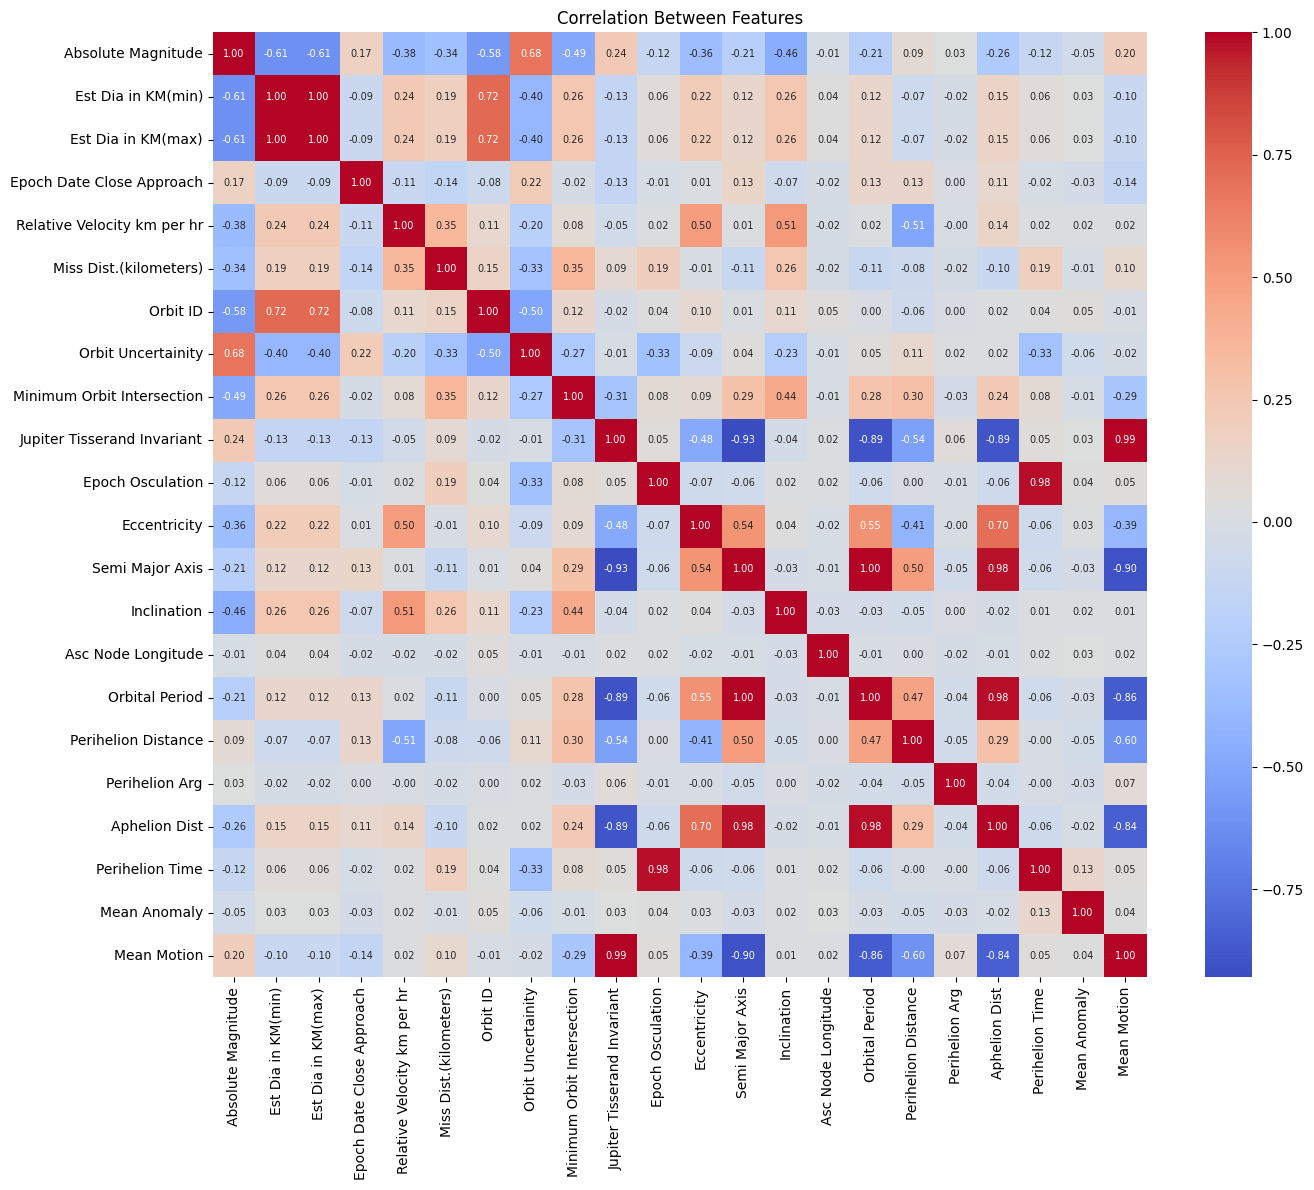

In [11]:
# Select numeric features (excluding target) for correlation check
numeric_features = df_clean.drop(columns=['Hazardous']).columns

# Calculate correlation matrix
corr_matrix = df_clean[numeric_features].corr()

# Plot as heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', annot_kws={"size": 7})
plt.title('Correlation Between Features')
plt.savefig('/kaggle/working/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

## 10. Removing Additional Highly Correlated Features

In [12]:
# Drop features that are >0.9 correlated with another feature already kept
# Keeping: Semi Major Axis (represents orbit size group)
# Keeping: Epoch Osculation (represents epoch/time group)
# Keeping: Est Dia in KM(min) (represents size group)

additional_drops = [
    'Est Dia in KM(max)',       # redundant with (min)
    'Orbital Period',            # redundant with Semi Major Axis
    'Aphelion Dist',             # redundant with Semi Major Axis
    'Jupiter Tisserand Invariant', # redundant with Semi Major Axis / Mean Motion
    'Mean Motion',                # redundant with Semi Major Axis
    'Perihelion Time',           # redundant with Epoch Osculation
]

df_clean = df_clean.drop(columns=additional_drops)
print(df_clean.shape)
df_clean.columns.tolist()

(4687, 17)


['Absolute Magnitude',
 'Est Dia in KM(min)',
 'Epoch Date Close Approach',
 'Relative Velocity km per hr',
 'Miss Dist.(kilometers)',
 'Orbit ID',
 'Orbit Uncertainity',
 'Minimum Orbit Intersection',
 'Epoch Osculation',
 'Eccentricity',
 'Semi Major Axis',
 'Inclination',
 'Asc Node Longitude',
 'Perihelion Distance',
 'Perihelion Arg',
 'Mean Anomaly',
 'Hazardous']